# Chapter 07 딥러닝을 시작합니다
## 07-3 신경망 모델 훈련
* 일반적으로 사이킷런에서 제공하는 머신러닝 알고리즘들은 좋은 성능을 내기 위해 매개변수를 조정하고 훈련하는 과정을 반복. 이런 알고리즘들은 모델의 구조가 어느 정도 고정되어 있다고 느낄 수 있음.
* 반면에 딥러닝에서는 모델의 구조를 직접 만든다는 느낌이 훨씬 강함. 층을 추가하고 층에 있는 뉴런의 개수와 활성화 함수를 결정하는 일들이 그러함.
### 손실 곡선
* 실은 케라스의 ```fit()``` 메서드는 History 클래스 객체를 반환. History 객체에는 훈련 과정에서 계산한 지표, 즉 손실과 정확도 값이 저장되어 있음.

In [1]:
from tensorflow import keras
from sklearn.model_selection import train_test_split
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()
train_scaled = train_input / 255.0
train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42
)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
def model_fn(a_layer=None):
  model = keras.Sequential()
  model.add(keras.layers.Flatten(input_shape=(28,28)))
  model.add(keras.layers.Dense(100, activation='relu'))
  if a_layer:
    model.add(a_layer)
  model.add(keras.layers.Dense(10, activation='softmax'))
  return model

* if 구문을 제외하면 이 코드는 이전 절에서 만든 것과 동일한 모델을 만듦. if 구문의 역할은 ```model_fn()``` 함수에 (a_layer 매개변수로) 케라스 층을 추가하면 은닉층 뒤에 또 하나의 층을 추가하는 것.
* 여기서는 a_layer 매개변수로 층을 추가하지 않고 단순하게 ```model_fn()``` 함수를 호출. 그리고 모델 구조를 출력하면 이전 절과 동일한 모델이라는 것을 확인할 수 있음.

In [4]:
model = model_fn()
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=5, verbose=0)

> verbose=0이 뭐죠?
> * verbose 매개변수는 훈련 과정 출력을 조절. 기본값은 1로 이전 절에서처럼 에포크마다 진행 막대와 함께 손실 등의 지표가 출력됨. 2로 바꾸면 진행 막대를 빼고 출력.

In [6]:
print(history.history.keys())

dict_keys(['accuracy', 'loss'])


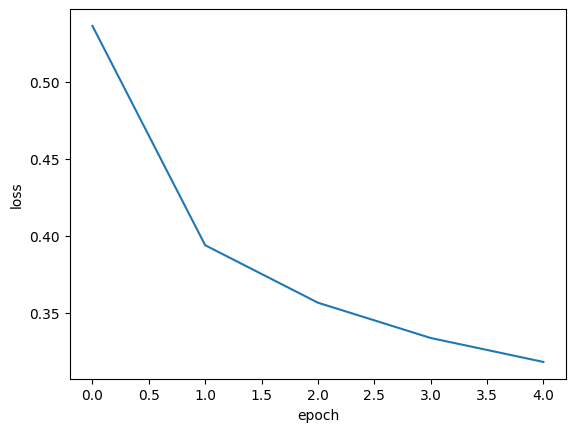

In [7]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

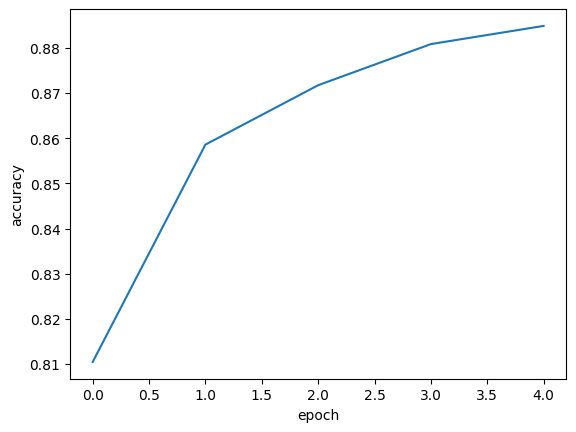

In [8]:
plt.plot(history.history['accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


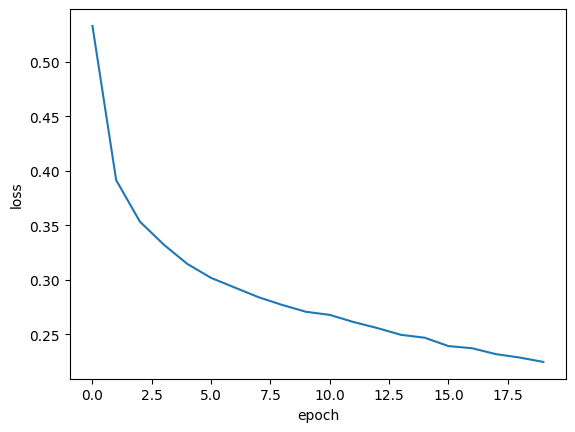

In [9]:
model = model_fn()
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=20, verbose=0)
plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

* 예상대로 손실이 잘 감소. -> 이전보다 더 나은 모델을 훈련한 것일까? 이전에 배웠던 것 중에 놓친 것이 있지 않나?

### 검증 손실
* 에포크에 따른 과대적합과 과소적합을 파악하려면 훈련 세트에 대한 점수뿐만 아니라 검증 세트에 대한 점수도 필요. -> 앞에서처럼 훈련 세트의 손실만 그려서는 안 됨.

> 손실을 사용하는 것과 정확도를 사용하는 것은 어떤 차이가 있나요?
> * 인공 신경망 모델이 최적화하는 대상은 정확도가 아니라 손실 함수. 이따금 손실 감소에 비례하여 정확도가 높아지지 않는 경우도 있음. 따라서 모델이 잘 훈련되었는지 판단하려면 정확도보다는 손실 함수의 값을 확인하는 것이 더 나음.

* 에포크마다 검증 손실을 계산하기 위해 케라스 모델의 ```fit()``` 메서드에 검증 데이터를 전달할 수 있음.

In [10]:
model = model_fn()
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=20, verbose=0, validation_data=(val_scaled, val_target))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


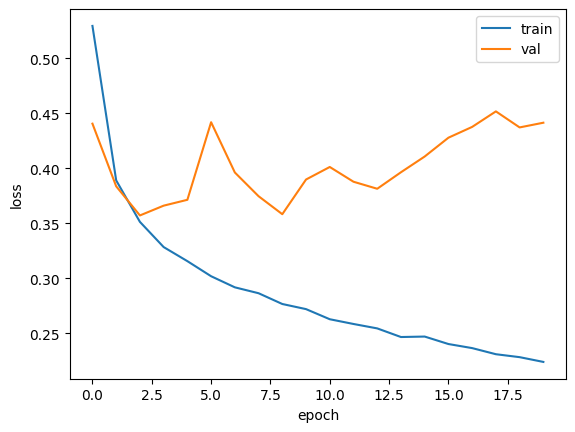

In [12]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

* 훈련 손실은 꾸준히 감소하기 때문에 전형적인 과대적합 모델이 만들어짐. 검증 손실이 상승하는 시점을 가능한 뒤로 늦추면 검증 세트에 대한 손실이 줄어들 뿐만 아니라 검증 세트에 대한 정확도도 증가할 것.
* 기본 RMSprop 옵티마이저는 많은 문제에서 잘 동작. 만약 이 옵티마이저 대신 다른 옵티마이저를 테스트해 본다면 Adam이 좋은 선택. Adam은 적응적 학습률을 사용하기 때문에 에포크가 진행되면서 학습률의 크기를 조정할 수 있음.

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


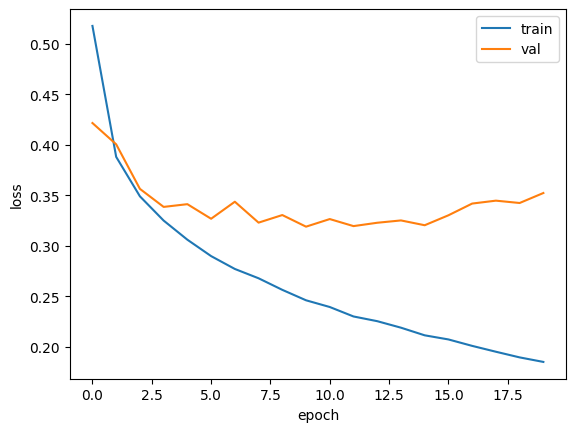

In [13]:
model = model_fn()
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=20, verbose=0, validation_data=(val_scaled, val_target))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

* 검증 손실 그래프에 여전히 요동이 남아 있지만 열 번째 에포크까지 전반적인 감소 추세가 이어지고 있음. 이는 Adam 옵티마이저가 이 데이터셋에 잘 맞는다는 것을 보여 줌.

### 드롭아웃
* **드롭아웃dropout**은 딥러닝의 아버지로 불리는 제프리 힌턴Geoffrey Hinton이 소개. 이 방식은 다음 그림처럼 훈련 과정에서 충에 있는 일부 뉴런을 랜덤하게 꺼서(즉 뉴런의 출력을 0으로 만들어) 과대적합을 막음.
* 어떤 샘플을 처리할 때는 은닉층의 두 번째 뉴런이 드롭아웃되어 $h_{2}$ 출력이 없음. 다른 샘플을 처리할 때는 은닉층의 첫 번째 뉴런이 드롭아웃되어 $h_{1}$ 출력이 없음. 뉴런은 랜덤하게 드롭아웃되고 얼마나 많은 뉴런을 드롭할지는 우리가 정해야 할 또 다른 하이퍼파라미터.
* 드롭아웃이 왜 과대적합을 막을까? 이전 층의 일부 뉴런이 랜덤하게 꺼지면 특정 뉴런에 과대하게 의존하는 것을 줄일 수 있고 모든 입력에 대해 주의를 기울여야 함. 일부 뉴런의 출력이 없을 수 있다는 것을 감안하면 이 신경망은 더 안정적인 예측을 만들 수 있을 것.
* 또 다른 해석은 앞의 드롭아웃이 적용된 2개의 신경망 그림을 보면 드롭아웃을 적용해 훈련하는 것은 마치 2개의 신경망을 앙상블 하는 것처럼 상상할 수 있음. 5장에서 보았듯이 앙상블은 과대적합을 막아 주는 아주 좋은 기법.
* 케라스에서는 드롭아웃을 keras.layers 패키지 아래 Dropout 클래스로 제공. 어떤 층의 뒤에 드롭아웃을 두어 이 층의 출력을 랜덤하게 0으로 만드는 것. 드롭아웃이 층처럼 사용되지만 훈련되는 모델 파라미터는 없음.

In [14]:
model = model_fn(keras.layers.Dropout(0.3))
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

* 출력 결과에서 볼 수 있듯이 은닉층 뒤에 추가된 드롭아웃 층(Dropout)은 훈련된느 모델 파라미터가 없음. 또한 입력과 출력의 크기가 같음. 일부 뉴런의 출력을 0으로 만들지만 전체 출력 배열의 크기를 바꾸지는 않음.
* 물론 훈련이 끝난 뒤에 평가나 예측을 수행할 때는 드롭아웃을 적용하지 말아야 함. 훈련된 모든 뉴런을 사용해야 올바른 예측을 수행할 수 있겠음. 그렇다면 모델을 훈련한 다음 층을 다시 빼야 할까? -> 아님. 똑똑하게도 텐서플로와 케라스는 모델을 평가와 예측에 사용할 때는 자동으로 드롭아웃을 적용하지 않음. 그래서 마음 편하게 검증 점수를 계산할 수 있음.

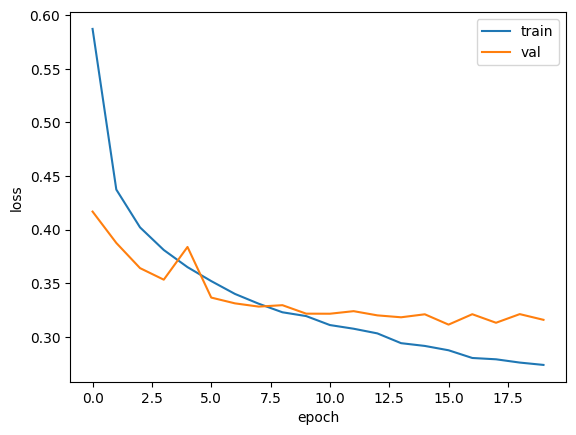

In [15]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=20, verbose=0, validation_data=(val_scaled, val_target))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

* 과대적합이 확실히 줄었음.
* 이 모델은 20번의 에포크 동안 훈련을 했기 때문에 결국 다소 과대적합 되어 있음. -> 과대적합 되지 않은 모델을 얻기 위해 에포크 횟수를 10으로 하고 다시 훈련해야겠음!

### 모델 저장과 복원
* 나중에 한빛 마켓의 패션 럭키백 런칭에 사용하려면 이 모델을 저장해야 함.

In [19]:
model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_scaled, train_target, epochs=10, verbose=0, validation_data=(val_scaled, val_target))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


* 케라스 모델은 훈련된 모델의 파라미터를 저장하는 간편한 ```save_weights()``` 메서드를 제공. 기본적으로 이 메서드는 텐서플로의 체크포인트 포맷으로 저장하지만 파일의 확장자가 '.h5'일 경우 HDF5 포맷으로 저장.

In [29]:
model.save_weights('model.weights.h5') # 현재 save_weights()는 파일 이름이 반드시 .weights.h5로 끝나야 합

* 또한 모델 구조와 모델 파라미터를 함께 저장하는 ```save()``` 메서드도 제공. 기본적으로 이 메서드는 텐서플로의 SavedModel 포맷으로 저장하지만 파일의 확장자가 '.h5'일 경우 HDF5 포맷으로 저장.

In [24]:
model.save('model-whole.h5')

In [25]:
!ls -al *.h5

-rw-r--r-- 1 root root 976600 Sep 16 14:10 model.weights.h5
-rw-r--r-- 1 root root 978584 Sep 16 14:10 model-whole.h5
-rw-r--r-- 1 root root 978584 Sep 16 14:10 model.whole.h5


* 두 가지 실험.
* 첫 번째는 훈련을 하지 않은 새로운 모델을 만들고 model.weights.h5 파일에서 훈련된 모델 파라미터를 읽어서 사용.
* 두번째는 아예 model-whole.h5 파일에서 새로운 모델을 만들어 바로 사용.

In [30]:
model = model_fn(keras.layers.Dropout(0.3))
model.load_weights('model.weights.h5')

* 훈련하지 않은 새로운 모델을 만들고 이전에 저장했던 모델 파라미터를 적재. 이때 사용하는 메서드는 ```save_weights()```와 쌍을 이루는 ```load_weights()``` 메서드.

> 모델 파라미터를 적재하는 조건이 있나요?
> * ```load_weights()``` 메서드를 사용하려면 ```save_weights()``` 메서드로 저장했던 모델과 정확히 같은 구조를 가져야 함. 그렇지 않으면 에러가 발생. 여기에서는 ```model_fn()``` 함수를 사용해 동일한 모델을 만들어 사용했음.

* 이 모델의 검증 정확도를 확인해 보겠음. 케라스에서 예측을 수행하는 ```predict()``` 메서드는 사이킷런과 달리 샘플마다 10개의 클래스에 대한 확률을 반환. 패션 MNIST 데이터셋이 다중 분류 문제이기 때문.

> 케라스에는 확률말고 그냥 클래스를 예측해 주는 메서드는 없나요?
> * 케라스 모델에는 ```predict_classes()``` 메서드가 있지만 향후 사라질 예정이기 때문에 이 책에서는 케라스 문서에서 권장하는 대로 ```predict()``` 메서드를 사용.

> ```evaluate()``` 메서드를 왜 사용하지 않나요?
> * 모델 파라미터를 읽은 후 ```evaluate()``` 메서드를 사용하여 정확도를 출력할 수도 있음. 하지만 ```evaluate()``` 메서드는 손실을 계산하기 위해 반드시 먼저 ```compile()``` 메서드를 실행해야 함.

In [31]:
import numpy as np
val_labels = np.argmax(model.predict(val_scaled), axis=-1)
print(np.mean(val_labels == val_target))

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 925us/step
0.14141666666666666


* 모델의 ```predict()``` 메서드 결과에서 가장 큰 값을 고르기 위해 넘파이 ```argmax()``` 함수를 사용했음. 이 함수는 배열에서 가장 큰 값의 인덱스를 반환. 예를 들어 배열의 첫 번째 원소가 가장 큰 값일 경우 0을 반환.
* ```argmax()``` 함수의 axis=-1은 배열의 마지막 차원을 따라 최댓값을 고름. 검증 세트는 2차원 배열이기 때문에 마지막 차원은 1이 됨.
* axis=1이면 열을 따라 각 행의 최댓값의 인덱스를 선택하고, axis=0이면 행을 따라 각 열의 최댓값의 인덱스를 선택.
* 그다음 라인은 ```argmax()```로 고른 인덱스(val_labels)와 타깃(val_target)을 비교. 두 배열에서 각 위치의 값이 같으면 1이 되고 다르면 0이 됨. 이를 평균하면 정확도가 됨.

In [32]:
model = keras.models.load_model('model-whole.h5')
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8775 - loss: 0.3405


[0.34053343534469604, 0.8774999976158142]

* 같은 모델을 저장하고 다시 불러들였기 때문에 위와 동일한 정확도를 얻었음.

> 여기에서는 어떻게 ```evaluate()``` 메서드를 사용할 수 있나요?
> * `load_model()` 함수는 모델 파라미터뿐만 아니라 모델 구조와 옵티마이저 상태까지 모두 복원하기 때문에 `evaluate()` 메서드를 사용할 수 있음. 텐서플로 2.3에서는 `load_model()` 함수의 버그 때문에 `evaluate()` 메서드를 사용하기 전에 `compile()` 메서드를 호출해야 함.

* 모델을 두 번씩 훈련하지 않고 한 번에 끝낼 수는 없을까?

### 콜백
* **콜백callback**은 훈련 과정 중간에 어떤 작업을 수행할 수 있게 하는 객체로 keras.callbacks 패키지 아래에 있는 클래스들임. ```fit()``` 메서드의 callbacks 매개변수에 리스트로 전달하여 사용.
* save_best_only=True 매개변수를 지정하여 가장 낮은 검증 점수를 만드는 모델을 저장할 수 있음.

In [33]:
model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-model.h5', save_best_only=True)
model.fit(train_scaled, train_target, epochs=20, verbose=0,
          validation_data=(val_scaled, val_target),
          callbacks=[checkpoint_cb])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model = keras.models.load_model('best-model.h5')
model.evaludate(val_scaled, val_target)

* ModelCheckpoint 콜백이 가장 낮은 검증 점수의 모델을 자동으로 저장해 주었음. 하지만 여전히 20번의 에포크 동안 훈련을 함. 사실 검증 점수가 상승하기 시작하면 그 이후에는 과대적합이 더 커지기 때문에 훈련을 계속할 필요가 없음. 이때 훈련을 중지하면 컴퓨터 자원과 시간을 아낄 수 있음. 이렇게 과대적합이 시작되기 전에 훈련을 미리 중지하는 것을 **조기 종료early stopping**라고 부르며, 딥러닝 분야에서 널리 사용함.
* 조기 종료는 훈련 에포크 횟수를 제한하는 역할이지만 모델이 과대적합되는 것을 막아 주기 때문에 규제 방법 중 하나로 생각할 수도 있음.
* 케라스에는 조기 종료를 위한 EarlyStopping 콜백을 제공. 이 콜백의 patience 매개변수는 검증 점수가 향상되지 않더라도 참을 에포크 횟수로 지정. 예를 들어 다음 코드에서처럼 patience=2로 지정하면 2번 연속 검증 점수가 향상되지 않으면 훈련을 중지. 또한 restore_best_weights 매개변수를 True로 지정하면 가장 낮은 검증 손실을 낸 모델 파라미터로 되돌림.
* EarlyStopping 콜백을 ModelCheckpoint 콜백과 함께 사용하면 가장 낮은 검증 손실의 모델을 파일에 저장하고 검증 손실이 다시 상승할 때 훈련을 중지할 수 있음. 또한 훈련을 중지한 다음 현재 모델의 파라미터를 최상의 파라미터로 되돌림.

In [34]:
model = model_fn(keras.layers.Dropout(0.3))
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
checkpoint_cb = keras.callbacks.ModelCheckpoint('best-model.h5', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)
history = model.fit(train_scaled, train_target, epochs=20, verbose=0,
                    validation_data=(val_scaled, val_target),
                    callbacks=[checkpoint_cb, early_stopping_cb])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [35]:
print(early_stopping_cb.stopped_epoch)

9


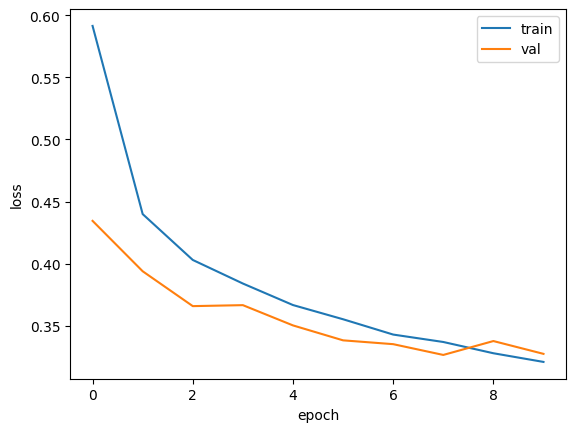

In [36]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

* 10번째 에포크에서 가장 낮은 손실을 기록했고 열세 번째 에포크에서 훈련이 중지되었음. 조기 종료 기법을 사용하면 안심하고 에포크 횟수를 크게 지정해도 괜찮음. 컴퓨터 자원과 시간을 아낄 수 있고 ModelCheckpoint 콜백과 함께 사용하면 최상의 모델을 자동으로 저장해 주므로 편리.

In [37]:
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8812 - loss: 0.3265


[0.3264808654785156, 0.8811666369438171]